# Tensor population experiments
When populating the tensor from the extracted vectors, multiple strategies can be followed
- Counting: += 1 for every xyz occurence in the tensor
- Pointwise mutual information for higher order data: SI1 and SI2
- SI1: specific interaction information

## Defining the functions
Van de Cruys, T. (2011). Two Multivariate Generalizations of Pointwise Mutual Information. In C. Biemann & E. Giesbrecht (Eds.), Proceedings of the Workshop on Distributional Semantics and Compositionality (pp. 16–20). Association for Computational Linguistics. https://aclanthology.org/W11-1303/

We adapt these formulas to take the negative log, so that higher values correspond to stronger interactions, similar to PMI.

In [15]:
from math import log
from collections import Counter

# We need separate ones, as the same word in a different role should be counted differently
c_x = Counter()
c_y = Counter()
c_z = Counter()
c_xy = Counter()
c_yz = Counter()
c_xz = Counter()
c_xyz = Counter()

# counts = Counter()
# probs = Counter()
p_x = Counter()
p_y = Counter()
p_z = Counter()
p_xy = Counter()
p_yz = Counter()
p_xz = Counter()
p_xyz = Counter()


# these experiments used Counts directly as probabilities. We forgot to normalize them.

We use the vectors extracted from previous steps to calculate the counts.
See POSExperiments.ipynb for extraction details.

In [19]:
def count_specific_interaction_information(x, y, z):
    if min(c_x[x], c_y[y], c_z[z], c_xy[(x,y)], c_yz[(y,z)], c_xz[(x,z)], c_xyz[(x,y,z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SI1')
    sii = - log(
        (c_xy[(x,y)] * c_yz[(y,z)] * c_xz[(x,z)])
        /
        (c_x[x] * c_y[y] * c_z[z] * c_xyz[(x,y,z)])
    )
    return sii

def count_specific_correlation(x, y, z):
    if min(c_x[x], c_y[y], c_z[z], c_xyz[(x,y,z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SI1')
    sc = - log(
        c_xyz[(x,y,z)]
        /
        (c_x[x] * c_y[y] * c_z[z])
    )
    return sc

def pos_specific_interaction_information(x, y, z):
    if min(p_x[x], p_y[y], p_z[z], p_xy[(x,y)], p_yz[(y,z)], p_xz[(x,z)], p_xyz[(x,y,z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SI1')
    # we need probabilities, not counts

    sii = log(
        (p_xy[(x,y)] * p_yz[(y,z)] * p_xz[(x,z)])
        /
        (p_x[x] * p_y[y] * p_z[z] * p_xyz[(x,y,z)])
    )
    return sii

def pos_specific_correlation(x, y, z):
    if min(p_x[x], p_y[y], p_z[z], p_xyz[(x,y,z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SI1')
    sc = log(
        p_xyz[(x,y,z)]
        /
        (p_x[x] * p_y[y] * p_z[z])
    )
    return sc

PosixPath('/home/pricie/stefa/pc/data/hello')

In [16]:
import csv
from utils import DATA_DIR

# data = "data/fineweb_dutch_vectors.csv"

# data = "data/opensubtitles_dutch_vectors.csv"
data = DATA_DIR / "fineweb_dutch_vectors.csv"
with open(data, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    vectors = list(reader)
# first we build the vocabularies and the clean vectors
clean_vectors = []
for vector in vectors[1:]:
    v = vector[0] if vector[0] != "" else "~"
    s = vector[1] if vector[1] != "" else "~"
    o = vector[2] if vector[2] != "" else "~"
    clean_vectors.append((v, s, o))
    
# we build up the counts
total = len(clean_vectors)
for v, s, o in clean_vectors:
    c_x[v] += 1
    c_y[s] += 1
    c_z[o] += 1
    c_xy[(v,s)] += 1
    c_yz[(s,o)] += 1
    c_xz[(v,o)] += 1
    c_xyz[(v,s,o)] += 1
    p_x[v] += 1/total
    p_y[s] += 1/total
    p_z[o] += 1/total
    p_xy[(v,s)] += 1/total
    p_yz[(s,o)] += 1/total
    p_xz[(v,o)] += 1/total
    p_xyz[(v,s,o)] += 1/total


print("Counts built")
# we save normalised versions of the counts for probability estimates

Counts built


## Sizes for the tensor
considering most common 500
26795
Tensor dims: V=498, S=499, O=500
Total size: 124251000 entries (~0.46 GB as float32)

considering most common 750
32348
Tensor dims: V=742, S=749, O=750
Total size: 416818500 entries (~1.55 GB as float32)

considering most common 1000
36559
Tensor dims: V=990, S=999, O=1000
Total size: 989010000 entries (~3.68 GB as float32)

considering most common 1500
42619
Tensor dims: V=1460, S=1494, O=1500
Total size: 3271860000 entries (~12.19 GB as float32)

##  we can also opt for a minimum count threshold (common in literature)

In [8]:
k = 750

subset_a = []
for (v,s,o, *rest) in clean_vectors:
    # we check if all three are above the threshold
    if counts[v] >= k and counts[s] >= k and counts[o] >= k:
        subset_a.append((v,s,o))

In [17]:
# we consider only the top N elements in each dimension
k = 750

m_c_v = [a for (a, b) in c_x.most_common(k)]
m_c_s = [a for (a, b) in c_y.most_common(k)]
m_c_o = [a for (a, b) in c_z.most_common(k)]
subset_t = []

for (v,s,o, *rest) in clean_vectors:
    if v in m_c_v and s in m_c_s and o in m_c_o:
        subset_t.append((v, s, o))
print(len(subset_t))
# 1) Build vocabularies in frequency order (stable & useful later)
vocab_v = [v for v, _ in Counter([v for v, _, _ in subset_t]).most_common()]
vocab_s = [s for s, _ in Counter([s for _, s, _ in subset_t]).most_common()]
vocab_o = [o for o, _ in Counter([o for _, _, o in subset_t]).most_common()]

V, S, O = len(vocab_v), len(vocab_s), len(vocab_o)

v2i = {v: i for i, v in enumerate(vocab_v)}
s2i = {s: i for i, s in enumerate(vocab_s)}
o2i = {o: i for i, o in enumerate(vocab_o)}
print(f"Tensor dims: V={V}, S={S}, O={O}")
print(f"Total size: {V * S * O} entries (~{(V * S * O * 4) / (1024 ** 3):.2f} GB as float32)")
print()

790926
Tensor dims: V=750, S=750, O=750
Total size: 421875000 entries (~1.57 GB as float32)



In [20]:
import numpy as np
from tqdm import tqdm
tensor = np.zeros((V, S, O), dtype=np.float32)
sii_tensor = np.zeros((V, S, O), dtype=np.float32)
sc_tensor = np.zeros((V, S, O), dtype=np.float32)
pos_sii_tensor = np.zeros((V, S, O), dtype=np.float32)
pos_sc_tensor = np.zeros((V, S, O), dtype=np.float32)

for v, s, o in tqdm(subset_t):
    vi = v2i[v]
    si = s2i[s]
    oi = o2i[o]
    tensor[vi, si, oi] += 1 # regular counting
    sii_tensor[vi, si, oi] = count_specific_interaction_information(v, s, o) # SI1 0_population -> First version summed here for each occurence
    sc_tensor[vi, si, oi] = count_specific_correlation(v, s, o) # SI2 0_population -> First version summed here for each occurence
    pos_sii_tensor[vi, si, oi] = pos_specific_interaction_information(v, s, o) # positive SI1 0_population
    pos_sc_tensor[vi, si, oi] = pos_specific_correlation(v, s, o) # positive SI2 0_population
print("Tensors populated")

100%|██████████| 790926/790926 [00:10<00:00, 73654.62it/s] 

Tensors populated


In [21]:
import torch
# we explicitly make them torch tensors
tensor = torch.tensor(tensor)
sii_tensor = torch.tensor(sii_tensor)
sc_tensor = torch.tensor(sc_tensor)
pos_sii_tensor = torch.tensor(pos_sii_tensor)
pos_sc_tensor = torch.tensor(pos_sc_tensor)
# we make inversed versions


In [22]:
# we check if the ratio of positive, negative and zero values in each tensor
def tensor_stats(tensor):
    total = tensor.numel()
    positive = (tensor > 0).sum().item()
    negative = (tensor < 0).sum().item()
    zero = (tensor == 0).sum().item()
    print(f"Total entries: {total}")
    print(f"Positive entries: {positive} ({(positive / total) * 100:.2f}%)")
    print(f"Negative entries: {negative} ({(negative / total) * 100:.2f}%)")
    print(f"Zero entries: {zero} ({(zero / total) * 100:.2f}%)")
    print()
print("Base tensor stats:")
tensor_stats(tensor)
print("SII tensor stats:")
tensor_stats(sii_tensor)
print("SC tensor stats:")
tensor_stats(sc_tensor)
print("Positive SII tensor stats:")
tensor_stats(pos_sii_tensor)
print("Positive SC tensor stats:")
tensor_stats(pos_sc_tensor)



Base tensor stats:
Total entries: 421875000
Positive entries: 104520 (0.02%)
Negative entries: 0 (0.00%)
Zero entries: 421770480 (99.98%)

SII tensor stats:
Total entries: 421875000
Positive entries: 104520 (0.02%)
Negative entries: 0 (0.00%)
Zero entries: 421770480 (99.98%)

SC tensor stats:
Total entries: 421875000
Positive entries: 104520 (0.02%)
Negative entries: 0 (0.00%)
Zero entries: 421770480 (99.98%)

Positive SII tensor stats:
Total entries: 421875000
Positive entries: 27350 (0.01%)
Negative entries: 77170 (0.02%)
Zero entries: 421770480 (99.98%)

Positive SC tensor stats:
Total entries: 421875000
Positive entries: 92079 (0.02%)
Negative entries: 12441 (0.00%)
Zero entries: 421770480 (99.98%)



# Inspection
We will check for some common verbs what the "highest scoring" argument *combinations* are

In [23]:
def inspect_verb(tensor, test_verb):
    verb_index = v2i[test_verb]
    # we will check which (o,s) pairs have the highest counts with this verb
    count_slice = tensor[verb_index, :, :]
    # we extract the max values and their indices
    values, indices = torch.topk(count_slice.flatten(), k=10)
    coords = [np.unravel_index(idx.item(), count_slice.shape) for idx in indices]
    results = []
    for i in range(len(values)):
        s_idx, o_idx = coords[i]
        s_word = vocab_s[s_idx]
        o_word = vocab_o[o_idx]
        results.append((s_word, o_word, values[i].item()))
    return results

def inspect_subj(tensor, test_subj):
    subj_index = s2i[test_subj]
    # we will check which (v,o) pairs have the highest counts with this subject
    count_slice = tensor[:, subj_index, :]
    # we extract the max values and their indices
    values, indices = torch.topk(count_slice.flatten(), k=10)
    coords = [np.unravel_index(idx.item(), count_slice.shape) for idx in indices]
    results = []
    for i in range(len(values)):
        v_idx, o_idx = coords[i]
        v_word = vocab_v[v_idx]
        o_word = vocab_o[o_idx]
        results.append((v_word, o_word, values[i].item()))
    return results

def inspect_obj(tensor, test_obj):
    obj_index = o2i[test_obj]
    # we will check which (v,s) pairs have the highest counts with this object
    count_slice = tensor[:, :, obj_index]
    # we extract the max values and their indices
    values, indices = torch.topk(count_slice.flatten(), k=10)
    coords = [np.unravel_index(idx.item(), count_slice.shape) for idx in indices]
    results = []
    for i in range(len(values)):
        v_idx, s_idx = coords[i]
        v_word = vocab_v[v_idx]
        s_word = vocab_s[s_idx]
        results.append((v_word, s_word, values[i].item()))
    return results
from itertools import zip_longest

def print_top10_side_by_side(a, b, c, titles=("tensor", "sii", "sc")):
    # a, b, c are lists like: [(w1, w2, value), ...]
    cols = [a, b, c]

    # compute pair string lengths for nice alignment
    def pair_len(item):
        if item is None: return 0
        s, o, _ = item
        return len(f"{s}–{o}")

    max_pair = max(pair_len(x) for col in cols for x in (col or []))
    pair_w  = max(12, min(40, max_pair))  # clamp for readability
    val_w   = 10

    def fmt(item):
        if item is None:
            return " " * (pair_w + 1 + val_w)
        s, o, v = item
        return f"{s}–{o:<{pair_w - len(f'{s}–')}} {v:>{val_w}}"

    # headers
    head = " | ".join(f"{t.title():<{pair_w + 1 + val_w}}" for t in titles)
    rule = "-+-".join("-" * (pair_w + 1 + val_w) for _ in titles)
    print(head)
    print(rule)

    # rows
    for rank, (x, y, z) in enumerate(zip_longest(a, b, c), start=1):
        left   = fmt(x)
        mid    = fmt(y)
        right  = fmt(z)
        print(f"{rank:>2}. {left} | {mid} | {right}")



In [25]:
test_verb = "spelen"
t_ins = inspect_verb(tensor, test_verb)
sii_ins = inspect_verb(sii_tensor, test_verb)
sc_ins = inspect_verb(sc_tensor, test_verb)
# we zippedly print the results
# Print side-by-side
print_top10_side_by_side(t_ins, sii_ins, sc_ins, titles=("base", "sii", "sc"))
# now the positive versions
print("\nPositive versions:\n")
t_ins = inspect_verb(tensor, test_verb)
sii_ins = inspect_verb(pos_sii_tensor, test_verb)
sc_ins = inspect_verb(pos_sc_tensor, test_verb)
# we zippedly print the results
# Print side-by-side
print_top10_side_by_side(t_ins, sii_ins, sc_ins, titles=("base", "pos_sii", "pos_sc"))


Base                     | Sii                      | Sc                      
-------------------------+--------------------------+-------------------------
 1. ~–~                198.0 | het–nacht     19.93451499938965 | ik–dat        29.86896514892578
 2. we–~               116.0 | iets–grap     19.558324813842773 | ~–het         29.50082015991211
 3. je–~               114.0 | jongen–iets   19.473079681396484 | zij–~         28.829933166503906
 4. ik–~               108.0 | dat–leven     19.29511070251465 | we–dat        28.579700469970703
 5. hij–~               79.0 | meid–ons      18.921127319335938 | ~–iets        28.548267364501953
 6. ze–~                59.0 | iemand–jullie 18.826553344726562 | het–~         28.51129722595215
 7. u–~                 56.0 | zij–man       18.51288414001465 | ik–~          28.506994247436523
 8. jullie–~            23.0 | jij–tijd      18.399147033691406 | dat–~         28.484607696533203
 9. jij–~               19.0 | groep–wat     18.39767837

# Sparse creation

In [1]:
from utils import DATA_DIR
import csv
import numpy as np
from collections import Counter

path_to_vectors = DATA_DIR / "vectors" / "fineweb_dutch_vectors_ids.csv"

p_x = Counter() # probabilities
p_y = Counter()
p_z = Counter()
p_xy = Counter()
p_yz = Counter()
p_xz = Counter()
p_xyz = Counter()



def specific_interaction_information(x, y, z):
    if min(p_x[x], p_y[y], p_z[z], p_xy[(x,y)], p_yz[(y,z)], p_xz[(x,z)], p_xyz[(x,y,z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SII')
    sii = log(
        (p_xy[(x,y)] * p_yz[(y,z)] * p_xz[(x,z)])
        /
        (p_x[x] * p_y[y] * p_z[z] * p_xyz[(x,y,z)])
    )
    return sii

def specific_correlation(x, y, z):
    if min(p_x[x], p_y[y], p_z[z], p_xyz[(x,y,z)]) == 0:
        raise ValueError('One of the probabilities is zero, cannot compute SC')
    sc = log(
        p_xyz[(x,y,z)]
        /
        (p_x[x] * p_y[y] * p_z[z])
    )
    return sc




# with open(path_to_vectors, "r", encoding="utf-8") as f:
#     reader = csv.reader(f)
#     entries = list(reader)
#     vectors = []
#     for row in entries:
#         # entries consist of "id", "(v,s,o)", "sentence"
#         vector = row[1]
#         # vector is a string representation of a tuple, we convert it back to tuple
#         vector = tuple(vector.strip("()").replace("'", "").split(", "))
#         vectors.append(vector)
vectors = []
with open(path_to_vectors, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader, None)  # skip header if there is one
    for row in reader:
        vector = row[1]
        # vector is a string representation of a tuple, we convert it back to tuple
        vector = tuple(vector.strip("()").replace("'", "").split(", "))
        (v,s,o) = vector[:3]
        v = v or "~"
        s = s or "~"
        o = o or "~"
        vectors.append((v, s, o))

        p_x[v] += 1
        p_y[s] += 1
        p_z[o] += 1
        p_xy[(v, s)] += 1
        p_yz[(s, o)] += 1
        p_xz[(v, o)] += 1
        p_xyz[(v, s, o)] += 1

total_len = len(vectors)
# convert all counts to probabilities in place
for counter in [p_x, p_y, p_z, p_xy, p_yz, p_xz, p_xyz]:
    for key in counter:
        counter[key] /= total_len
print("Probabilities computed.")

Probabilities computed.


In [25]:
from tqdm import tqdm
import torch
from collections import Counter
from math import log

top_k = 10000
m_c_v = [v for (v, count) in p_x.most_common(top_k)]
m_c_s = [s for (s, count) in p_y.most_common(top_k)]
m_c_o = [o for (o, count) in p_z.most_common(top_k)]
# we check if all have at least top_k counts
if not len(m_c_v) == len(m_c_s) == len(m_c_o) == top_k:
    print(f"Warning: less than {top_k} unique elements in one of the dimensions.")

# use top-k directly as vocabs
vocab_v = m_c_v
vocab_s = m_c_s
vocab_o = m_c_o

V, S, O = len(vocab_v), len(vocab_s), len(vocab_o)

v2i = {v: i for i, v in enumerate(vocab_v)}
s2i = {s: i for i, s in enumerate(vocab_s)}
o2i = {o: i for i, o in enumerate(vocab_o)}

# for filtering triples, use sets for fast membership
v_set = set(vocab_v)
s_set = set(vocab_s)
o_set = set(vocab_o)

subset_t = []
for v, s, o in vectors:
    if v in v_set and s in s_set and o in o_set:
        subset_t.append((v, s, o))

total_size = V*S*O
print(f"Tensor dims: V={V}, S={S}, O={O}")
print(f"Total size: {total_size} entries (~{(V * S * O * 4) / (1024 ** 3):.2f} GB as float32)")


# --- NEW: build sparse representation directly ---
triple_counts = Counter(subset_t)

indices = []
count_values = []
sii_values = []
sc_values = []

for (v, s, o), count in tqdm(triple_counts.items()):
    vi = v2i[v]
    si = s2i[s]
    oi = o2i[o]

    # store indices (vi, si, oi)
    indices.append([vi, si, oi])
    count_values.append(float(count))

    # these may raise ValueError if some probability is zero (same behavior as before)
    sii_values.append(float(specific_interaction_information(v, s, o)))
    sc_values.append(float(specific_correlation(v, s, o)))

if len(indices) == 0:
    # no non-zero entries; create empty sparse tensors
    indices_tensor = torch.empty((3, 0), dtype=torch.long)
    count_tensor = torch.sparse_coo_tensor(indices_tensor,
                                           torch.empty((0,), dtype=torch.float32),
                                           size=(V, S, O))
    sii_tensor = torch.sparse_coo_tensor(indices_tensor,
                                         torch.empty((0,), dtype=torch.float32),
                                         size=(V, S, O))
    sc_tensor = torch.sparse_coo_tensor(indices_tensor,
                                        torch.empty((0,), dtype=torch.float32),
                                        size=(V, S, O))
else:
    indices_tensor = torch.tensor(indices, dtype=torch.long).t()  # shape (3, nnz)
    count_values_tensor = torch.tensor(count_values, dtype=torch.float32)
    sii_values_tensor = torch.tensor(sii_values, dtype=torch.float32)
    sc_values_tensor = torch.tensor(sc_values, dtype=torch.float32)

    size = (V, S, O)

    count_tensor = torch.sparse_coo_tensor(indices_tensor, count_values_tensor, size=size)
    sii_tensor = torch.sparse_coo_tensor(indices_tensor, sii_values_tensor, size=size)
    sc_tensor = torch.sparse_coo_tensor(indices_tensor, sc_values_tensor, size=size)

    # ensure canonical form (sorted indices, summed duplicates)
    count_tensor = count_tensor.coalesce()
    sii_tensor = sii_tensor.coalesce()
    sc_tensor = sc_tensor.coalesce()

print(f"created sparse tensors of shape {sc_tensor.shape} with {count_tensor._nnz()} non-zero entries")

Tensor dims: V=10000, S=10000, O=10000
Total size: 1000000000000 entries (~3725.29 GB as float32)


100%|██████████| 557643/557643 [00:03<00:00, 177293.28it/s]


created sparse tensors of shape torch.Size([10000, 10000, 10000]) with 557643 non-zero entries


In [16]:
# we save this to disk and check size
sparse_dir = DATA_DIR / "tensors" / "fineweb_dutch_vectors_ids" / "sparse"
# sparse_dir.mkdir(parents=True, exist_ok=True)

In [17]:
# we save with torch
torch.save(count_tensor, sparse_dir / f"count_{top_k}.pt")
torch.save(sii_tensor, sparse_dir / f"sii_{top_k}.pt")

In [20]:
import pandas as pd
import re

data = {
    "top_k": [750, 1000, 1250, 2500, 5000],
    "sparse": ["5 mb", "6 mb", "7 mb", "10 mb", "13 mb"],
    "dense": ["1.6 GB", "3.8 GB", "7.3 GB", "58.21 GB", "(? 466 GB)"],
    "non_zero_entities": [184779, 222621, 254185, 358612, 461901]
}

df = pd.DataFrame(data)

def to_mb(value):
    # extract number
    num = re.findall(r"[\d.]+", value)
    if not num:
        return None
    num = float(num[0])
    # check unit
    if "GB" in value.upper():
        return num * 1000
    return num  # already in mb

df["sparse_mb"] = df["sparse"].apply(to_mb)
df["dense_mb"] = df["dense"].apply(to_mb)
df["dense_gb"] = df["dense"].apply(to_mb)/1000
df


,top_k,sparse,dense,non_zero_entities,sparse_mb,dense_mb,dense_gb
0,750,5 mb,1.6 GB,184779,5.0,1600.0,1.60
1,1000,6 mb,3.8 GB,222621,6.0,3800.0,3.80
2,1250,7 mb,7.3 GB,254185,7.0,7300.0,7.30
3,2500,10 mb,58.21 GB,358612,10.0,58210.0,58.21
4,5000,13 mb,(? 466 GB),461901,13.0,466000.0,466.00


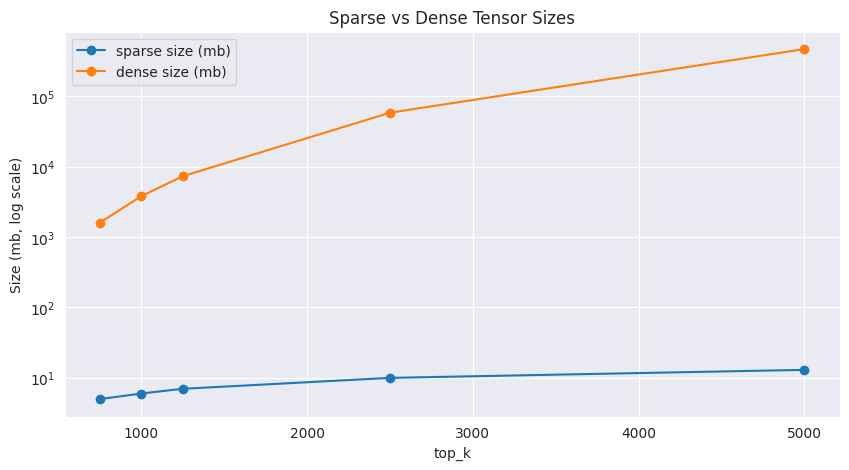

In [22]:
# we plot sparse vs dense sizes, and separately
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df["top_k"], df["sparse_mb"], label="sparse size (mb)", marker='o')
plt.plot(df["top_k"], df["dense_mb"], label="dense size (mb)", marker='o')
plt.yscale("log")
plt.xlabel("top_k")
plt.ylabel("Size (mb, log scale)")
plt.title("Sparse vs Dense Tensor Sizes")
plt.legend()
plt.grid(True)
plt.show()